# DATA 410 FINAL PROJECT - GDAAN08


### ✱ Installing & Importing Libraries

In [1]:
pip install pandas scipy tabulate seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### ✱ Reading CSV File

In [8]:
df = pd.read_csv("dataset/Global_Economy_Indicators.csv")

### ✱ Data Cleaning ( Column Names)


In [ ]:
def clean_col_name(col_name):
    """Cleans column names to snake_case format."""
    col_name = col_name.strip().lower()
    col_name = col_name.replace(' ', '_').replace(',', '').replace('(', '').replace(')', '').replace('-', '_').replace('.', '').replace('/', '_')
    while '__' in col_name:
        col_name = col_name.replace('__', '_')
    return col_name.strip('_')

# Clean all column names
df.columns = [clean_col_name(col) for col in df.columns]

## Descriptive Statistics, Analytics & Visualisation

In [26]:
#Descriptive Statistics
key_stats_cols = ['gross_national_incomegni_in_usd', 'population', 'ama_exchange_rate', 
                  'exports_of_goods_and_services', 'imports_of_goods_and_services', 
                  'manufacturing_isic_d']
print("\n## 1. Descriptive Statistics for Key Indicators")
key_stats = df[key_stats_cols].describe()
print(key_stats.to_markdown(numalign="left", stralign="left"))


## 1. Descriptive Statistics for Key Indicators
|       | gross_national_incomegni_in_usd   | population   | ama_exchange_rate   | exports_of_goods_and_services   | imports_of_goods_and_services   | manufacturing_isic_d   |
|:------|:----------------------------------|:-------------|:--------------------|:--------------------------------|:--------------------------------|:-----------------------|
| count | 10512                             | 10512        | 10512               | 10491                           | 10470                           | 10469                  |
| mean  | 1.82526e+11                       | 2.85152e+07  | 357.396             | 4.67118e+10                     | 4.5915e+10                      | 3.09259e+10            |
| std   | 9.94214e+11                       | 1.1413e+08   | 2291.13             | 1.74886e+11                     | 1.80435e+11                     | 1.72391e+11            |
| min   | 3.56483e+06                       | 4359         | 4.3e-14   

### 1. Trend of Total GDP over the years ( Time Series Plot)

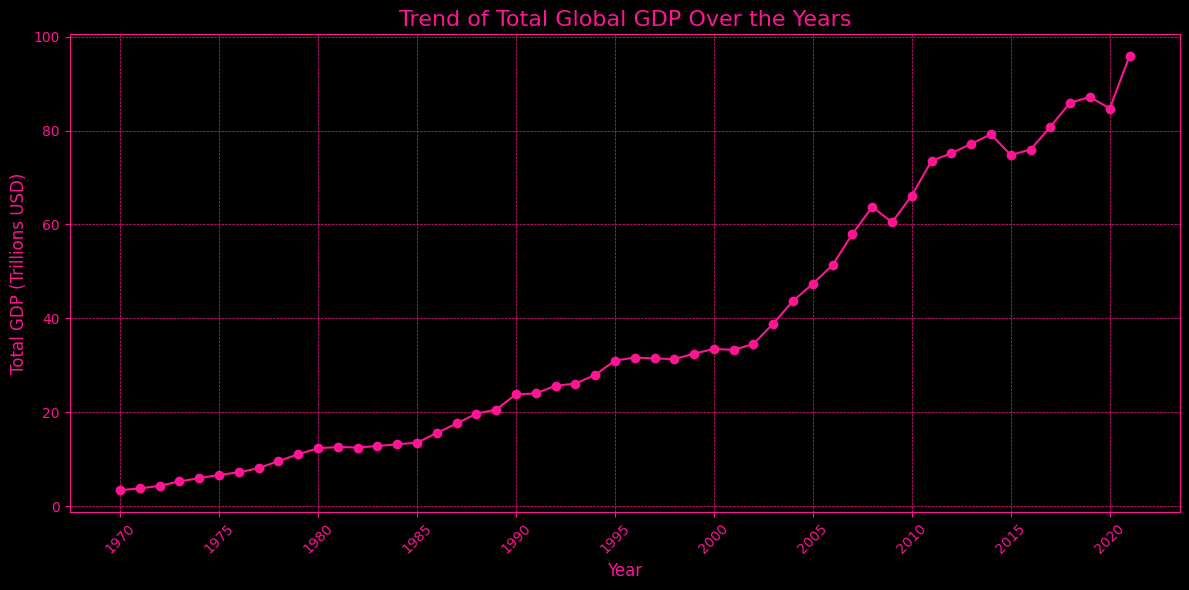

In [ ]:

# 1. Time Series Plot: Trend of Global GDP over the Years.
global_gdp = df.groupby('year')['gross_domestic_product_gdp'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(global_gdp['year'], global_gdp['gross_domestic_product_gdp'] / 1e12, marker='o', linestyle='-')
plt.title('Trend of Total Global GDP Over the Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total GDP (Trillions USD)', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(np.arange(global_gdp['year'].min(), global_gdp['year'].max()+1, 5), rotation=45)
plt.tight_layout()
plt.savefig('global_gdp_trend.png')
plt.show()

### 2. Top 10 Countries by Average GDP (Bar Chart)

/var/folders/pp/ty3m1h8j557f1gjjmkq2pnh00000gn/T/ipykernel_92975/3827785830.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='average_gdp_trillions_usd', y='country', data=top_10_gdp, palette='viridis')


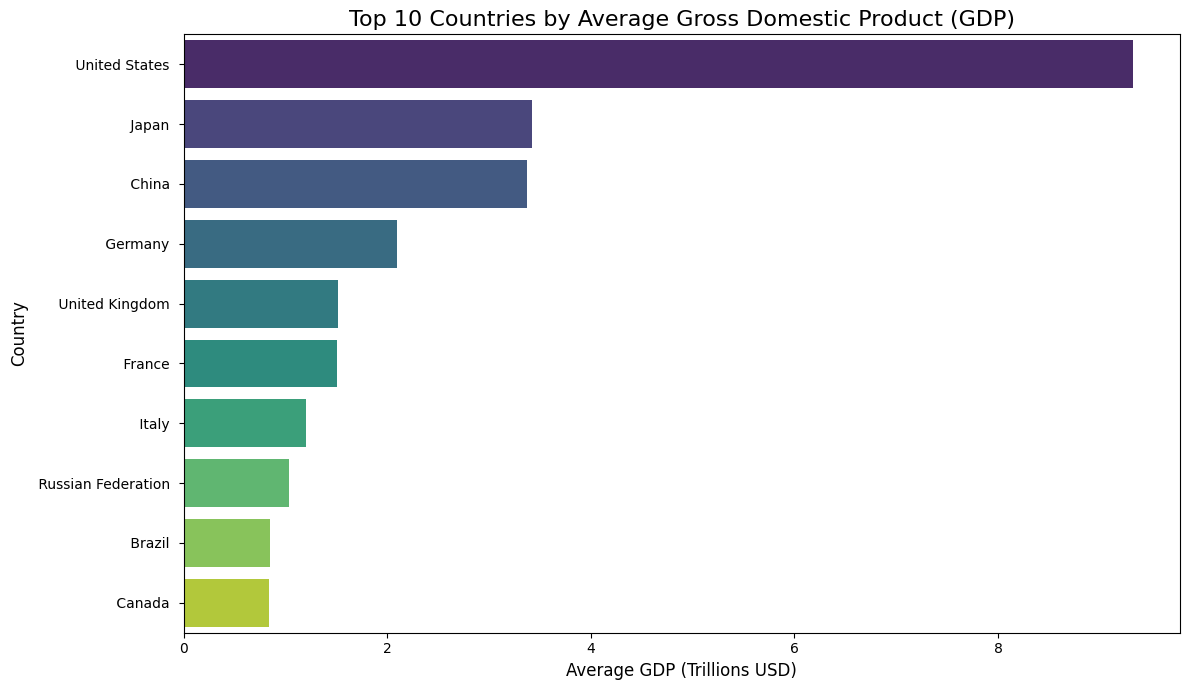

In [ ]:
# 2. Top 10 Countries by Average GDP
top_10_gdp = df.groupby('country')['gross_domestic_product_gdp'].mean().nlargest(10).reset_index()
plt.figure(figsize=(12, 7))
# Convert GDP to Trillions for better readability on the plot
top_10_gdp['average_gdp_trillions_usd'] = top_10_gdp['gross_domestic_product_gdp'] / 1e12
sns.barplot(x='average_gdp_trillions_usd', y='country', data=top_10_gdp, palette='viridis')
plt.title('Top 10 Countries by Average Gross Domestic Product (GDP)', fontsize=16)
plt.xlabel('Average GDP (Trillions USD)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.savefig('top_10_countries_avg_gdp.png')
plt.show()

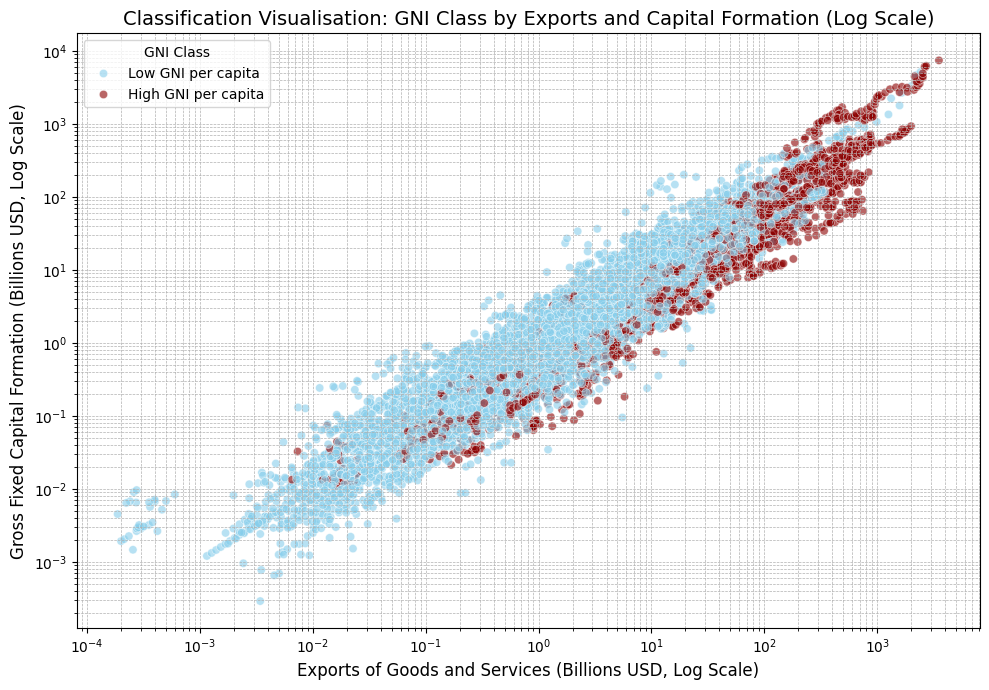

In [107]:
## 3. GNI Class by Exports & and Capitlization (Classification)
gni_threshold = df['per_capita_gni'].quantile(0.75)
df['gni_class'] = df['per_capita_gni'].apply(lambda x: 'High GNI per capita' if x >= gni_threshold else 'Low GNI per capita')

# Convert to Billions
df_classify['exports_billions'] = df_classify['exports_of_goods_and_services'] / 1e9
df_classify['capital_formation_billions'] = df_classify['gross_fixed_capital_formation_including_acquisitions_less_disposals_of_valuables'] / 1e9

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='exports_billions',
    y='capital_formation_billions',
    hue='gni_class',
    data=df_classify,
    alpha=0.6,
    palette={'Low GNI per capita': 'skyblue', 'High GNI per capita': 'darkred'}
)
plt.xscale('log')
plt.yscale('log')
plt.title('Classification Visualisation: GNI Class by Exports and Capital Formation (Log Scale)', fontsize=14)
plt.xlabel('Exports of Goods and Services (Billions USD, Log Scale)', fontsize=12)
plt.ylabel('Gross Fixed Capital Formation (Billions USD, Log Scale)', fontsize=12)
plt.legend(title='GNI Class')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.savefig('gni_class_classification_scatter.png')
plt.show()

### 4. Heat Map of Variable Correlation Trends

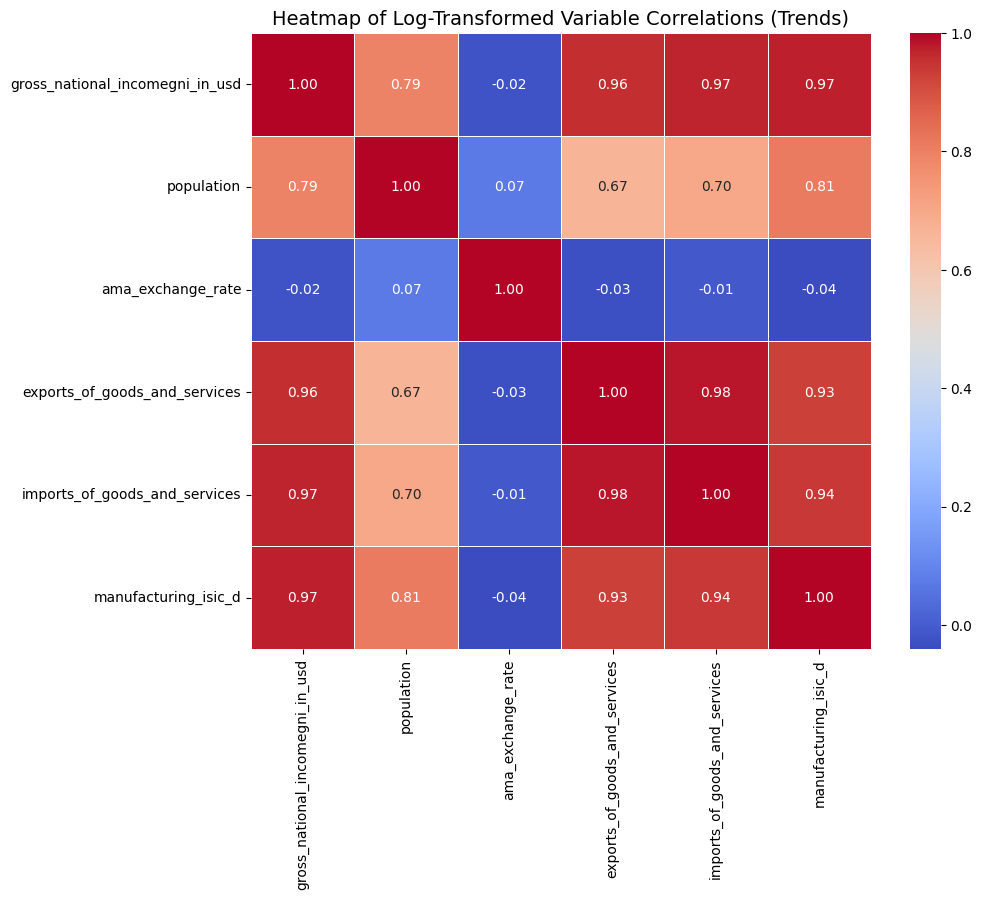

In [ ]:
# 4. Heat Map of Variable Correlation Trends
df_corr = df[key_stats_cols].apply(np.log)
corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap of Log-Transformed Variable Correlations (Trends)', fontsize=14)
plt.savefig('EDA_4_Correlation_Heatmap.png')
plt.show()

/var/folders/pp/ty3m1h8j557f1gjjmkq2pnh00000gn/T/ipykernel_92975/3350517479.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gni_class', y='log_population', data=df_pop_violin, palette='Spectral')


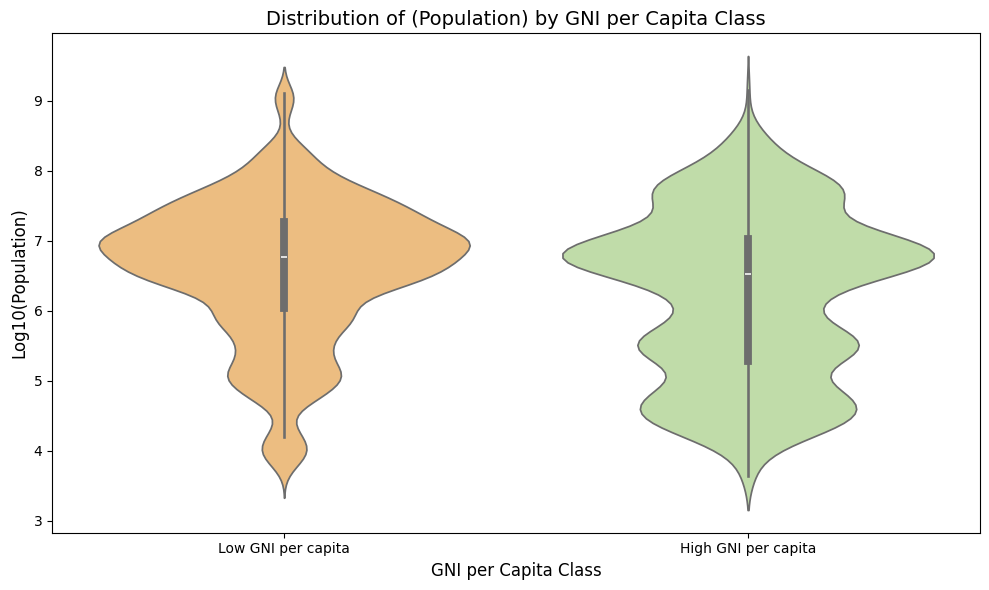

In [116]:
# 5. Distributuion of Population by GNI per Capita Class
gni_threshold = df['per_capita_gni'].quantile(0.75)
df['gni_class'] = df['per_capita_gni'].apply(lambda x: 'High GNI per capita' if x >= gni_threshold else 'Low GNI per capita')

# 12. New Violin Plot: Distribution of Log10(Population) by GNI Class
df_pop_violin = df.dropna(subset=['population', 'gni_class']).copy()

# Log transform population for better distribution visualization
df_pop_violin['log_population'] = np.log10(df_pop_violin['population'].clip(lower=1))

plt.figure(figsize=(10, 6))
sns.violinplot(x='gni_class', y='log_population', data=df_pop_violin, palette='Spectral')
plt.title('Distribution of (Population) by GNI per Capita Class', fontsize=14)
plt.xlabel('GNI per Capita Class', fontsize=12)
plt.ylabel('Log10(Population)', fontsize=12)
plt.tight_layout()
plt.savefig('violin_log_population_by_gni_class.png')
plt.show()

# Case Study: 

## Business Question 1: (Simple Linear Regression)

### A Development bank is testing the link between national investment levels and a country's capacity to produce goods for export.


--- Linear Regression Results (Question 1) [Exports vs Gross Capital Formation] ---
Slope: 0.5681054584639526
Intercept: 20726240769.563103
R-squared: 0.7510288026439083
P-value: 0.0
Standard error: 0.003201749702579754


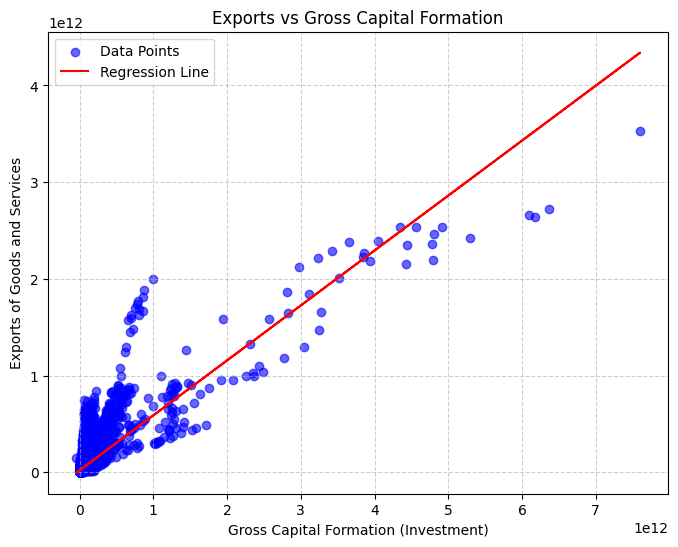

In [117]:
# ----------------------------------------------------------------
# Defining Variables:
Y_col = 'exports_of_goods_and_services'
X_col = 'gross_capital_formation'
df_model = df[[Y_col, X_col]].dropna().copy()
X = df_model[X_col].values
Y = df_model[Y_col].values
# ----------------------------------------------------------------
# Running Linear Regression Model
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(X, Y)
# Printing Results:
print("\n--- Linear Regression Results (Question 1) [Exports vs Gross Capital Formation] ---")
print("Slope:", slope)
print("Intercept:", intercept)
print("R-squared:", r_value**2)
print("P-value:", p_value)
print("Standard error:", std_err)
# ----------------------------------------------------------------
# Visualization
regression_line = slope * X + intercept
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, label='Data Points', color='blue', alpha=0.6)
plt.plot(X, regression_line, color='red', label='Regression Line')
plt.title('Exports vs Gross Capital Formation')
plt.xlabel('Gross Capital Formation (Investment)')
plt.ylabel('Exports of Goods and Services')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
# ----------------------------------------------------------------



## Business Question 2: (Linear Regression - Log Transformed)

### An Economic modeler is testing the fundamental linear correlation between the sheer size of a country's population and its Gross National Income (GNI)

Slope: 0.8530598072837207
Intercept: 10.058216495796284
R-squared: 0.6312
Intercept (B0): 10.0582
Coefficient for Log(Population) (B1 - Elasticity): 0.8531
Model: Log(Total GNI) = B0 + B1 * Log(Population)


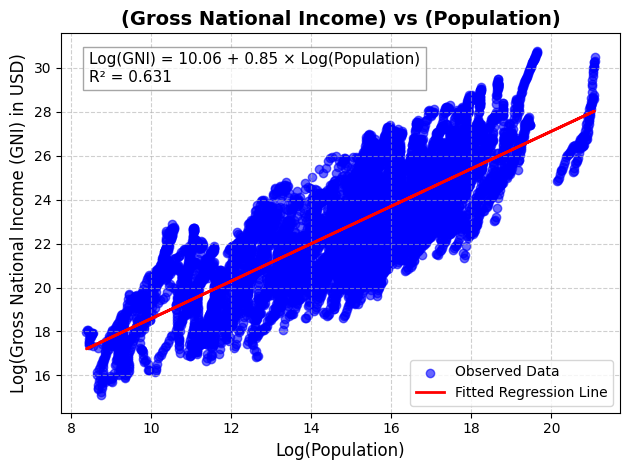

In [118]:
# ----------------------------------------------------------------
# Assigning Columns:
Y_col = 'gross_national_incomegni_in_usd'
X_col = 'population'
df_model = df[[Y_col, X_col]].dropna().copy()
# ----------------------------------------------------
# Log Transform data for Numerical Stability (Log-Log Model)
df_model['log_Y'] = np.log(df_model[Y_col] + 1)
df_model['log_X'] = np.log(df_model[X_col] + 1)
# ----------------------------------------------------
# Replacing Null Values & Assigning Variables:
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()
X = df_model['log_X']
Y = df_model['log_Y']
# ----------------------------------------------------
# Regression Calculation using NumPy
# np.polyfit performas a linear OLSfir and returns slope & intercept.
slope, intercept = np.polyfit(X, Y, 1)
Y_pred = slope * X + intercept
# Calculating R-Squared (SS_Res/SS_Total)
ss_res = np.sum((Y - Y_pred)**2)
ss_tot = np.sum((Y - Y.mean())**2)
r_squared = 1 - (ss_res / ss_tot)
# ----------------------------------------------------
# Printing Results:
print("Slope:", slope)
print("Intercept:", intercept)
print(f"R-squared: {r_squared:.4f}")
print(f"Intercept (B0): {intercept:.4f}")
print(f"Coefficient for Log(Population) (B1 - Elasticity): {slope:.4f}")
print(f"Model: Log(Total GNI) = B0 + B1 * Log(Population)")
# ----------------------------------------------------
# Visualisation:
plt.scatter(X, Y, color='blue', alpha=0.6, label='Observed Data')
plt.plot(X, Y_pred, color='red', linewidth=2, label='Fitted Regression Line')
plt.title('(Gross National Income) vs (Population)', fontsize=14, weight='bold')
plt.xlabel('Log(Population)', fontsize=12)
plt.ylabel('Log(Gross National Income (GNI) in USD)', fontsize=12)
equation_text = f"Log(GNI) = {intercept:.2f} + {slope:.2f} × Log(Population)\nR² = {r_squared:.3f}"
plt.text(
    0.05, 0.95, equation_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey')
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('Linear_Regression_GNI_vs_Population.png', dpi=300)
plt.show()
# ----------------------------------------------------




#

## Business Question 3 (Multiple Regression - Simple)

### A Supply Chain Manager wants to know how change in total domestic consumption collectively drives demand for international imports.


--- Multiple Regression Results (Question 3) [Imports vs Total Domestic Consumption] ---
Model: Imports = B0 + B1*Household Consumption + B2*Government Consumption
Test Set R-squared (Viability): 0.825185
Test Set RMSE: 70428592060.75
Intercept (B0): 0.00
Coefficient for Household Consumption (B1): -0.0604
Coefficient for Government Consumption (B2): 1.3100


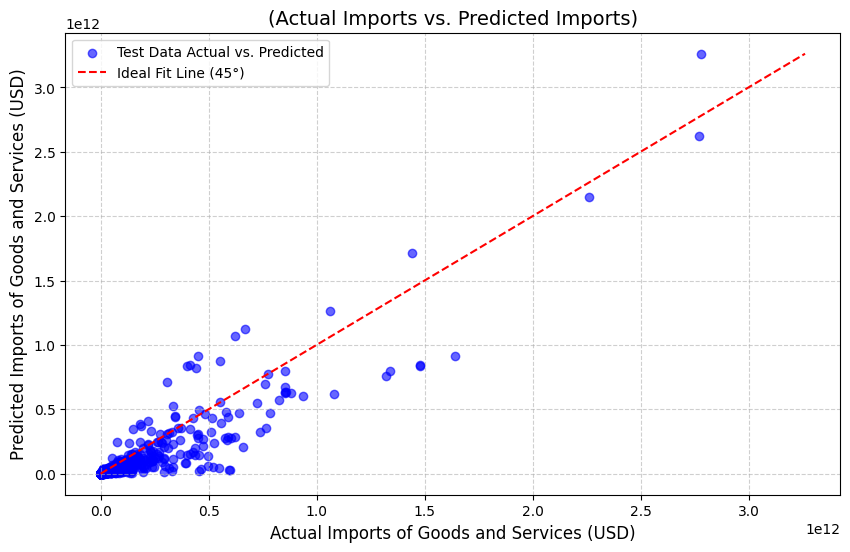

In [119]:
# ----------------------------------------------------
# Defining Variables:
Y_col = 'imports_of_goods_and_services'
X_cols = [
    'household_consumption_expenditure_including_non_profit_institutions_serving_households', 
    'general_government_final_consumption_expenditure'
]
df_model = df[[Y_col] + X_cols].dropna().copy()
# ----------------------------------------------------------------
# Multiple Regression Calculation
np.random.seed(42) # For reproducible split
shuffled_indices = np.random.permutation(len(df_model))
test_set_size = int(len(df_model) * 0.2)
test_indices = shuffled_indices[:test_set_size]
train_indices = shuffled_indices[test_set_size:]
train_data = df_model.iloc[train_indices]
test_data = df_model.iloc[test_indices]
# ----------------------------------------------------------------
# Prepare X data with intercept column for OLS
X_train_data = train_data[X_cols].values
X_test_data = test_data[X_cols].values
Y_train = train_data[Y_col].values
Y_test = test_data[Y_col].values
X_train = np.hstack([np.ones((X_train_data.shape[0], 1)), X_train_data])
X_test = np.hstack([np.ones((X_test_data.shape[0], 1)), X_test_data])
# ----------------------------------------------------------------
# Regression Calculation:
betas = np.linalg.lstsq(X_train, Y_train, rcond=None)[0]
# Prediction:
Y_pred_test = X_test @ betas
# Data Metrics Viability Calculation:
mse_test = np.mean((Y_test - Y_pred_test)**2)
rmse_test = np.sqrt(mse_test) # Root Mean Squared Error (RMSE)
# RSquared for Test Viability Metric:
ss_res_test = np.sum((Y_test - Y_pred_test)**2)
ss_tot_test = np.sum((Y_test - Y_test.mean())**2)
r_squared_test = 1 - (ss_res_test / ss_tot_test)
# ----------------------------------------------------------------
# Printing Results:
print("\n--- Multiple Regression Results (Question 3) [Imports vs Total Domestic Consumption] ---")
print(f"Model: Imports = B0 + B1*Household Consumption + B2*Government Consumption")
print(f"Test Set R-squared (Viability): {r_squared_test:.6f}")
print(f"Test Set RMSE: {rmse_test:.2f}")
print(f"Intercept (B0): {betas[0]:.2f}")
print(f"Coefficient for Household Consumption (B1): {betas[1]:.4f}")
print(f"Coefficient for Government Consumption (B2): {betas[2]:.4f}")
# ----------------------------------------------------------------
# Visualisation:
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, Y_pred_test, alpha=0.6, label='Test Data Actual vs. Predicted', color='blue')

min_val = min(Y_test.min(), Y_pred_test.min())
max_val = max(Y_test.max(), Y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit Line (45°)')

plt.title('(Actual Imports vs. Predicted Imports)', fontsize=14)
plt.xlabel('Actual Imports of Goods and Services (USD)', fontsize=12)
plt.ylabel('Predicted Imports of Goods and Services (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
plt.savefig('Multiple_Regression_Q8_Validated_Imports_vs_Consumption.png')
plt.show()


## Business Question 4: Multiple Regression

### A Trade Analyst wants to understand the linear impact of a country's exchange rate on its ability to export goods and services internationally


--- Multiple Regression Results (Question 4) [Export vs Manufaturing & Exchange Rates] ---
Model: Log(Exports) = B0 + B1*Log(Manufacturing) + B2*Log(Exchange Rate)
R-squared: 0.8673
Intercept (B0): 4.9804
Coefficient for Log(Manufacturing Output) (B1 - Elasticity): 0.8169
Coefficient for Log(AMA Exchange Rate) (B2 - Elasticity): -0.0541


/Users/farhaz/Documents/SAIT/Data Analytics/✱410/FInal Project/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/farhaz/Documents/SAIT/Data Analytics/✱410/FInal Project/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


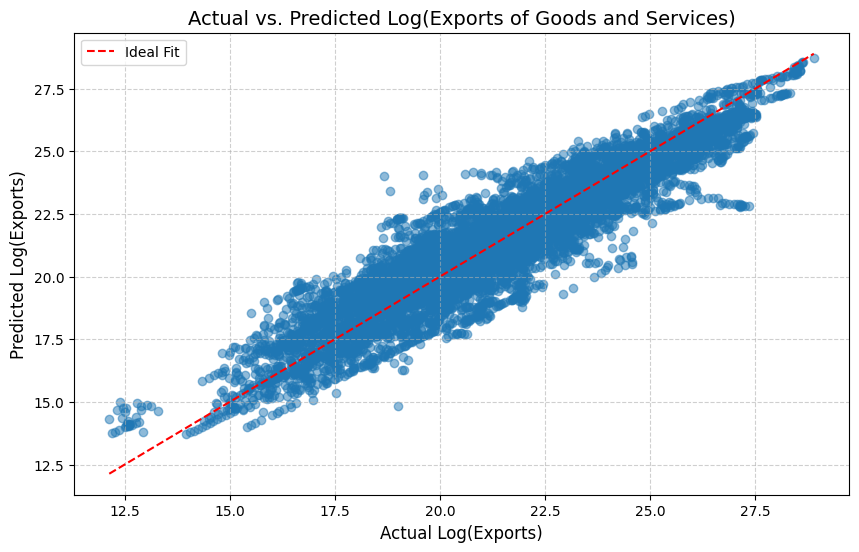

In [120]:
# ----------------------------------------------------
# Defining Variables:
Y_col = 'exports_of_goods_and_services'
X_cols = ['manufacturing_isic_d', 'ama_exchange_rate']
df_model = df[[Y_col] + X_cols].dropna().copy()
# ----------------------------------------------------
# Log Transformation for numerical stability:
df_model['log_Y'] = np.log(df_model[Y_col] + 1)
df_model['log_X1'] = np.log(df_model[X_cols[0]] + 1)
df_model['log_X2'] = np.log(df_model[X_cols[1]] + 1)
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()
Y = df_model['log_Y'].values
X_data = df_model[['log_X1', 'log_X2']].values
# Add intercept to X - Column:
X = np.hstack([np.ones((X_data.shape[0], 1)), X_data])
# Regression Calculation using NumPy Linear Algebra OLS Solution:
betas = np.linalg.lstsq(X, Y, rcond=None)[0]
# Calculate predicted Y values
Y_pred = X @ betas
# Calculate R-squared: R^2 = 1 - (SS_res / SS_tot)
ss_res = np.sum((Y - Y_pred)**2)
ss_tot = np.sum((Y - Y.mean())**2)
r_squared = 1 - (ss_res / ss_tot)
# ----------------------------------------------------
print("\n--- Multiple Regression Results (Question 4) [Export vs Manufaturing & Exchange Rates] ---")
print(f"Model: Log(Exports) = B0 + B1*Log(Manufacturing) + B2*Log(Exchange Rate)")
print(f"R-squared: {r_squared:.4f}")
print(f"Intercept (B0): {betas[0]:.4f}")
print(f"Coefficient for Log(Manufacturing Output) (B1 - Elasticity): {betas[1]:.4f}")
print(f"Coefficient for Log(AMA Exchange Rate) (B2 - Elasticity): {betas[2]:.4f}")
# ----------------------------------------------------
# Visualisation:
plt.figure(figsize=(10, 6))
plt.scatter(Y, Y_pred, alpha=0.5)
# Plot the ideal 45-degree line (Y_actual = Y_predicted)
min_val = min(Y.min(), Y_pred.min())
max_val = max(Y.max(), Y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit')
plt.title('Actual vs. Predicted Log(Exports of Goods and Services)', fontsize=14)
plt.xlabel('Actual Log(Exports)', fontsize=12)
plt.ylabel('Predicted Log(Exports)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.savefig('Multiple_Regression_Q6_Exports_Actual_vs_Predicted.png')
plt.show()
# ----------------------------------------------------
